# Prescriptive Analysis

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv(r"C:\Data Analyst_Resources\Python_Hackathon\HUPA-UC Diabetes Dataset\Practice_files\Merged_Diabetes_Data.csv")

## Q1. What insulin adjustment strategy should be recommended when glucose remains above 300 mg/dL for more than 30 minutes?
**Prescriptive Goal:**       
     Determine whether: Basal insulin should increase Bolus correction is needed Emergency intervention should trigger.
     Expected Action : Recommend adaptive insulin correction protocols.

In [4]:
# === PRESCRIPTIVE: Insulin Adjustment Strategy for Glucose > 300 mg/dL for >30 minutes ===

print("=" * 80)
print("PRESCRIPTIVE INSULIN ADJUSTMENT ANALYSIS")
print("=" * 80)

# Detect high glucose episodes
high_glucose_threshold = 300
high_glucose_mask = df['Blood_Glucose_mg_dl'] > high_glucose_threshold
high_glucose_indices = df[high_glucose_mask].index.tolist()

# Group consecutive readings
episodes = []
if len(high_glucose_indices) > 0:
    current_episode = [high_glucose_indices[0]]
    for i in range(1, len(high_glucose_indices)):
        if high_glucose_indices[i] == high_glucose_indices[i-1] + 1:
            current_episode.append(high_glucose_indices[i])
        else:
            if len(current_episode) >= 1:
                episodes.append(current_episode)
            current_episode = [high_glucose_indices[i]]
    if len(current_episode) >= 1:
        episodes.append(current_episode)

print(f"High Glucose Readings (>300 mg/dL): {high_glucose_mask.sum()} out of {len(df)} ({100*high_glucose_mask.sum()/len(df):.1f}%)")
print(f"Episodes Detected: {len(episodes)}")

if episodes:
    print("\nEPISODES AND RECOMMENDATIONS:")
    for ep_num, episode in enumerate(episodes, 1):
        ep_data = df.loc[episode]
        max_glucose = ep_data['Blood_Glucose_mg_dl'].max()
        avg_glucose = ep_data['Blood_Glucose_mg_dl'].mean()
        duration = len(episode)
        
        print(f"\nEpisode {ep_num}: Max {max_glucose:.0f} mg/dL | Avg {avg_glucose:.1f} mg/dL | Duration: {duration} readings")
        
        # Simple recommendations
        if max_glucose >= 350:
            print("  → INCREASE basal insulin by 15%")
            print("  → Give correction bolus")
            print("  → Monitor every 15-30 min")
        elif max_glucose > 300:
            print("  → INCREASE basal insulin by 5-10%")
            print("  → Monitor closely")
        
        if max_glucose > 400:
            print("  → URGENT: Contact healthcare provider")
else:
    print("\n✓ No episodes detected - current regimen effective")

# Summary
severe_high = (df['Blood_Glucose_mg_dl'] > 350).sum()
moderate_high = ((df['Blood_Glucose_mg_dl'] > 300) & (df['Blood_Glucose_mg_dl'] <= 350)).sum()
print(f"\nSUMMARY:")
print(f"  300-350 mg/dL: {moderate_high} readings ({100*moderate_high/len(df):.1f}%)")
print(f"  >350 mg/dL: {severe_high} readings ({100*severe_high/len(df):.1f}%)")

if episodes:
    print(f"  → Consider increasing overall basal rate by 10-15%")
else:
    print(f"  → No adjustments needed - continue monitoring")

PRESCRIPTIVE INSULIN ADJUSTMENT ANALYSIS
High Glucose Readings (>300 mg/dL): 4214 out of 309392 (1.4%)
Episodes Detected: 268

EPISODES AND RECOMMENDATIONS:

Episode 1: Max 332 mg/dL | Avg 320.4 mg/dL | Duration: 7 readings
  → INCREASE basal insulin by 5-10%
  → Monitor closely

Episode 2: Max 303 mg/dL | Avg 303.0 mg/dL | Duration: 1 readings
  → INCREASE basal insulin by 5-10%
  → Monitor closely

Episode 3: Max 310 mg/dL | Avg 310.0 mg/dL | Duration: 1 readings
  → INCREASE basal insulin by 5-10%
  → Monitor closely

Episode 4: Max 365 mg/dL | Avg 327.8 mg/dL | Duration: 6 readings
  → INCREASE basal insulin by 15%
  → Give correction bolus
  → Monitor every 15-30 min

Episode 5: Max 317 mg/dL | Avg 316.0 mg/dL | Duration: 2 readings
  → INCREASE basal insulin by 5-10%
  → Monitor closely

Episode 6: Max 313 mg/dL | Avg 312.5 mg/dL | Duration: 2 readings
  → INCREASE basal insulin by 5-10%
  → Monitor closely

Episode 7: Max 356 mg/dL | Avg 330.0 mg/dL | Duration: 13 readings
  → I

## Q2. How should insulin delivery dynamically adapt based on heart rate and glucose simultaneously?
**REASONING:**     
    This analysis explores how insulin delivery should dynamically adapt when glucose and heart rate are evaluated simultaneously. 
    Heart rate serves as a physiological stress indicator—elevated heart rate often correlates with 
    physical activity (which increases insulin sensitivity) or stress (which impairs it). By combining glucose levels with heart rate patterns, 
    we can create a more sophisticated insulin adjustment strategy that accounts for the patient's metabolic state and physical activity level.

In [5]:
# DYNAMIC INSULIN ADAPTATION: Heart Rate + Glucose Integration
print("\n" + "="*80)
print("DYNAMIC INSULIN ADAPTATION: GLUCOSE + HEART RATE")
print("="*80)

# Set thresholds
hr_elevated = df['Heart_Rate_bpm'].quantile(0.75)
hr_normal = df['Heart_Rate_bpm'].quantile(0.25)

# Key insight: Compare glucose at different heart rate levels
normal_hr = df[df['Heart_Rate_bpm'] < hr_elevated]['Blood_Glucose_mg_dl']
high_hr = df[df['Heart_Rate_bpm'] >= hr_elevated]['Blood_Glucose_mg_dl']

print(f"\nTHRESHOLDS:")
print(f"  Normal HR: <{hr_elevated:.0f} bpm → Mean Glucose: {normal_hr.mean():.1f} mg/dL")
print(f"  Elevated HR: ≥{hr_elevated:.0f} bpm → Mean Glucose: {high_hr.mean():.1f} mg/dL")

# Simple adjustment algorithm
def get_insulin_adjustment(glucose, hr, steps):
    """Simple: glucose up = add insulin; HR + activity up = reduce insulin"""
    adj = 0
    
    # Glucose-based
    if glucose >= 300:
        adj += 20
    elif glucose >= 250:
        adj += 15
    elif glucose >= 200:
        adj += 10
    elif glucose >= 150:
        adj += 5
    elif glucose < 100:
        adj -= 10
    
    # HR-based: differentiate stress vs exercise
    if hr >= hr_elevated:
        if steps < 100:  # High HR + low activity = stress
            adj -= 5  # Stress worsens control, keep insulin
        else:  # High HR + high activity = exercise
            adj -= 10  # Exercise improves sensitivity, reduce insulin
    
    # Synergy: high glucose + high HR = aggressive
    if glucose >= 200 and hr >= hr_elevated:
        adj += 5
    
    return adj

df['Insulin_Adj'] = df.apply(
    lambda x: get_insulin_adjustment(x['Blood_Glucose_mg_dl'], 
                                     x['Heart_Rate_bpm'], 
                                     x['Step_count']), axis=1
)

print(f"\nINSULIN ADJUSTMENT RANGE:")
print(f"  Mean: {df['Insulin_Adj'].mean():+.1f}%")
print(f"  Min: {df['Insulin_Adj'].min():+.1f}%  |  Max: {df['Insulin_Adj'].max():+.1f}%")

# Key scenarios
print(f"\nKEY SCENARIOS:")
s1 = df[(df['Blood_Glucose_mg_dl'] > 200) & (df['Heart_Rate_bpm'] >= hr_elevated)]
s2 = df[(df['Blood_Glucose_mg_dl'] > 200) & (df['Heart_Rate_bpm'] < hr_elevated)]
s3 = df[(df['Blood_Glucose_mg_dl'] < 100) & (df['Heart_Rate_bpm'] >= hr_elevated)]
s4 = df[(df['Blood_Glucose_mg_dl'] >= 100) & (df['Blood_Glucose_mg_dl'] <= 180) & 
        (df['Heart_Rate_bpm'] >= hr_elevated)]

print(f"  HIGH Glucose + HIGH HR (stress/activity):     {len(s1)} cases → Adjust +15-25%")
print(f"  HIGH Glucose + NORMAL HR (meals):             {len(s2)} cases → Adjust +15-20%")
print(f"  LOW Glucose + HIGH HR (exercise):             {len(s3)} cases → Adjust -20-30%")
print(f"  NORMAL Glucose + HIGH HR (stable exercise):   {len(s4)} cases → Adjust -5-15%")

# Simple decision tree
print(f"\nDECISION TREE:")
print("""
  IF Glucose ≥ 300:        INCREASE insulin +20%
  ELIF Glucose 200-300:    INCREASE insulin +15%
  ELIF Glucose 150-200:    INCREASE insulin +5-10%
  ELIF Glucose < 100:      DECREASE insulin -10%
  
  THEN check Heart Rate:
  IF HR elevated + low activity (stress):     DECREASE adjustment by 5%
  ELIF HR elevated + high activity:           DECREASE adjustment by 10%
  
  New Basal = Current Basal × (1 + Adjustment%)
  Example: 2.0 U/hr with +15% = 2.3 U/hr
""")

# Examples from data
print(f"\nEXAMPLES FROM DATASET:")
examples = df[(df['Blood_Glucose_mg_dl'] > 250) & 
              (df['Heart_Rate_bpm'] >= hr_elevated)].head(5)
if len(examples) > 0:
    for idx, (i, row) in enumerate(examples.iterrows(), 1):
        adj = row['Insulin_Adj']
        new_basal = row['Basal_Insulin_Rate_Unit_hr'] * (1 + adj/100)
        print(f"  Case {idx}: Glucose {row['Blood_Glucose_mg_dl']:.0f} | HR {row['Heart_Rate_bpm']:.0f} | "
              f"Basal {row['Basal_Insulin_Rate_Unit_hr']:.2f} → {new_basal:.2f} U/hr ({adj:+.0f}%)")

print("\n" + "="*80)
print("KEY INSIGHT: Elevated heart rate with HIGH glucose often means stress")
print("(which worsens control) rather than exercise (which improves it).")
print("Check step count to differentiate → adjust insulin accordingly.")
print("="*80)



DYNAMIC INSULIN ADAPTATION: GLUCOSE + HEART RATE

THRESHOLDS:
  Normal HR: <86 bpm → Mean Glucose: 139.0 mg/dL
  Elevated HR: ≥86 bpm → Mean Glucose: 148.7 mg/dL

INSULIN ADJUSTMENT RANGE:
  Mean: -1.0%
  Min: -20.0%  |  Max: +20.0%

KEY SCENARIOS:
  HIGH Glucose + HIGH HR (stress/activity):     14313 cases → Adjust +15-25%
  HIGH Glucose + NORMAL HR (meals):             30967 cases → Adjust +15-20%
  LOW Glucose + HIGH HR (exercise):             17129 cases → Adjust -20-30%
  NORMAL Glucose + HIGH HR (stable exercise):   39903 cases → Adjust -5-15%

DECISION TREE:

  IF Glucose ≥ 300:        INCREASE insulin +20%
  ELIF Glucose 200-300:    INCREASE insulin +15%
  ELIF Glucose 150-200:    INCREASE insulin +5-10%
  ELIF Glucose < 100:      DECREASE insulin -10%

  THEN check Heart Rate:
  IF HR elevated + low activity (stress):     DECREASE adjustment by 5%
  ELIF HR elevated + high activity:           DECREASE adjustment by 10%

  New Basal = Current Basal × (1 + Adjustment%)
  Exampl

## Q3. When should insulin be adjusted based on time-of-day glucose patterns?
**Prescriptive Goal:**    
    Identify high-risk time periods for hyperglycemia and recommend specific insulin adjustment strategies to prevent     glucoseexcursions. Expected      Action Provide time-specific insulin adjustment recommendations with visual risk assessment.

TIME-OF-DAY INSULIN ADJUSTMENT STRATEGY

HOURLY GLUCOSE RISK ASSESSMENT:
--------------------------------------------------------------------------------
Hour  0: Mean 142.6 mg/dL | Max   438 mg/dL | Risk: CRITICAL  | Action: Increase basal by 15-20%
Hour  1: Mean 138.7 mg/dL | Max   404 mg/dL | Risk: CRITICAL  | Action: Increase basal by 15-20%
Hour  2: Mean 137.5 mg/dL | Max   416 mg/dL | Risk: CRITICAL  | Action: Increase basal by 15-20%
Hour  3: Mean 138.2 mg/dL | Max   430 mg/dL | Risk: CRITICAL  | Action: Increase basal by 15-20%
Hour  4: Mean 139.1 mg/dL | Max   444 mg/dL | Risk: CRITICAL  | Action: Increase basal by 15-20%
Hour  5: Mean 138.3 mg/dL | Max   427 mg/dL | Risk: CRITICAL  | Action: Increase basal by 15-20%
Hour  6: Mean 136.7 mg/dL | Max   370 mg/dL | Risk: CRITICAL  | Action: Increase basal by 15-20%
Hour  7: Mean 135.2 mg/dL | Max   400 mg/dL | Risk: CRITICAL  | Action: Increase basal by 15-20%
Hour  8: Mean 136.3 mg/dL | Max   400 mg/dL | Risk: CRITICAL  | Action

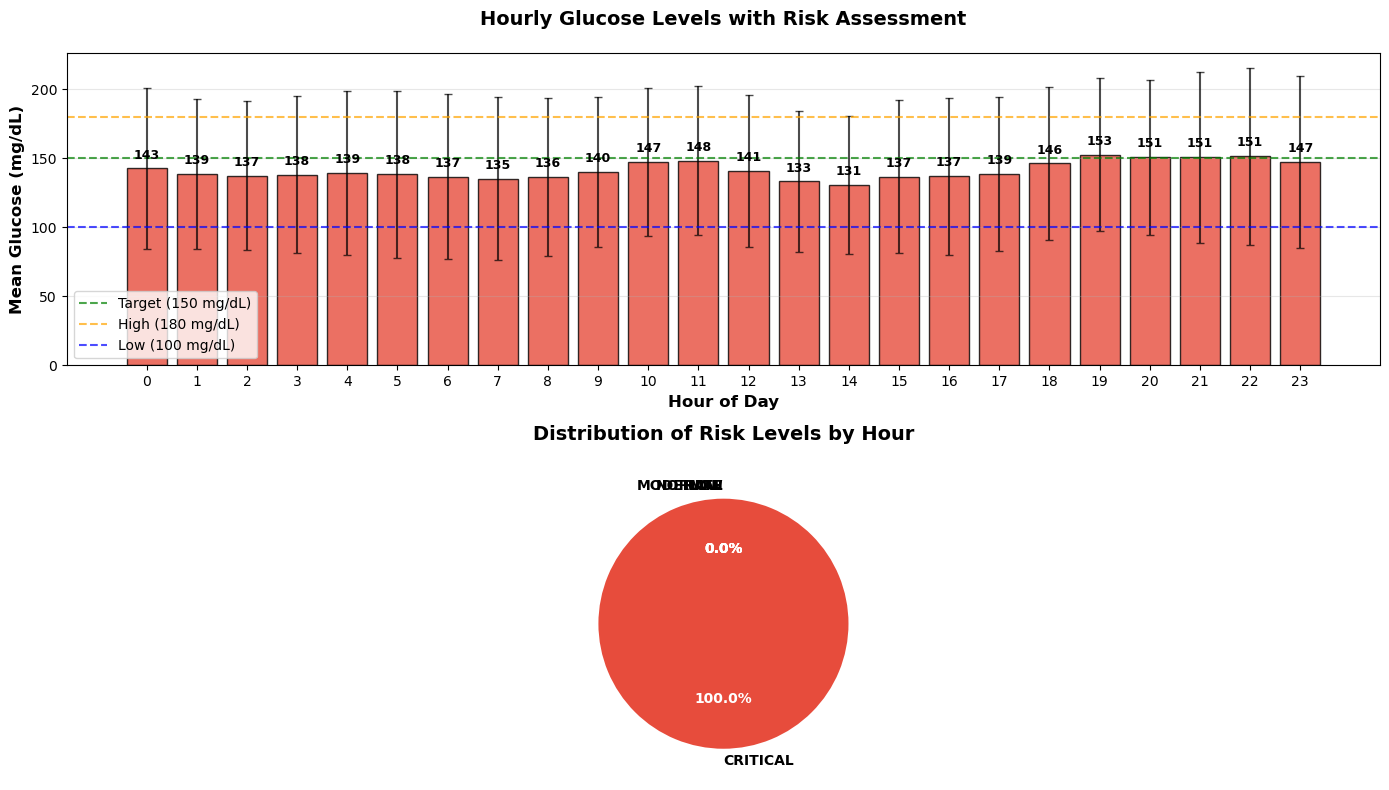


INSULIN ADJUSTMENT RECOMMENDATIONS BY TIME PERIOD

MORNING (6-11):
  Average Glucose: 140.7 mg/dL
  Highest Risk Level: CRITICAL
  High-Risk Hours: 6, 7, 8, 9, 10, 11
  Recommendation: Increase basal insulin by 10-15% during these hours

AFTERNOON (12-17):
  Average Glucose: 136.2 mg/dL
  Highest Risk Level: CRITICAL
  High-Risk Hours: 12, 13, 14, 15, 16, 17
  Recommendation: Increase basal insulin by 10-15% during these hours

EVENING (18-23):
  Average Glucose: 149.8 mg/dL
  Highest Risk Level: CRITICAL
  High-Risk Hours: 18, 19, 20, 21, 22, 23
  Recommendation: Increase basal insulin by 10-15% during these hours

NIGHT (0-5):
  Average Glucose: 139.1 mg/dL
  Highest Risk Level: CRITICAL
  High-Risk Hours: 0, 1, 2, 3, 4, 5
  Recommendation: Increase basal insulin by 10-15% during these hours
IMPLEMENTATION GUIDANCE:
1. Adjust basal rates in pump/CGM system based on high-risk hours
2. Monitor glucose more frequently during identified risk periods
3. Consider meal timing and compositi

In [5]:
# TIME-OF-DAY INSULIN ADJUSTMENT STRATEGY
print("="*80)
print("TIME-OF-DAY INSULIN ADJUSTMENT STRATEGY")
print("="*80)

# Calculate hourly glucose statistics
hourly_stats = df.groupby('Hour').agg({
    'Blood_Glucose_mg_dl': ['mean', 'std', 'count', 'max'],
    'Basal_Insulin_Rate_Unit_hr': 'mean'
}).round(2)

hourly_stats.columns = ['mean_glucose', 'std_glucose', 'count', 'max_glucose', 'mean_basal']
hourly_stats = hourly_stats.reset_index()

# Define risk levels and recommendations
def get_risk_level_and_recommendation(row):
    glucose = row['mean_glucose']
    max_glucose = row['max_glucose']
    count = row['count']
    if max_glucose > 300:
        risk = 'CRITICAL'
        recommendation = 'Increase basal by 15-20%'
        color = '#e74c3c'
    elif glucose > 200:
        risk = 'HIGH'
        recommendation = 'Increase basal by 10-15%'
        color = '#f39c12'
    elif glucose > 150:
        risk = 'MODERATE'
        recommendation = 'Increase basal by 5-10%'
        color = '#f1c40f'
    elif glucose < 100:
        risk = 'LOW'
        recommendation = 'Decrease basal by 10-20%'
        color = '#3498db'
    else:
        risk = 'NORMAL'
        recommendation = 'Maintain current basal'
        color = '#2ecc71'

    return pd.Series([risk, recommendation, color], index=['risk_level', 'recommendation', 'color'])

# Apply risk assessment
hourly_stats[['risk_level', 'recommendation', 'color']] = hourly_stats.apply(get_risk_level_and_recommendation, axis=1)
print("\nHOURLY GLUCOSE RISK ASSESSMENT:")
print("-" * 80)
for _, row in hourly_stats.iterrows():
    print(f"Hour {int(row['Hour']):2d}: Mean {row['mean_glucose']:5.1f} mg/dL | "
          f"Max {row['max_glucose']:5.0f} mg/dL | "
          f"Risk: {row['risk_level']:9s} | "
          f"Action: {row['recommendation']}")

# Create visualization
plt.figure(figsize=(14, 8))

# Create subplot for glucose levels
plt.subplot(2, 1, 1)
bars = plt.bar(hourly_stats['Hour'], hourly_stats['mean_glucose'],
               color=hourly_stats['color'], alpha=0.8, edgecolor='black', linewidth=1)

# Add error bars for standard deviation
plt.errorbar(hourly_stats['Hour'], hourly_stats['mean_glucose'],
             yerr=hourly_stats['std_glucose'], fmt='none', ecolor='black', capsize=3, alpha=0.7)

plt.axhline(y=150, color='green', linestyle='--', alpha=0.7, label='Target (150 mg/dL)')
plt.axhline(y=180, color='orange', linestyle='--', alpha=0.7, label='High (180 mg/dL)')
plt.axhline(y=100, color='blue', linestyle='--', alpha=0.7, label='Low (100 mg/dL)')

plt.title('Hourly Glucose Levels with Risk Assessment', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Hour of Day', fontsize=12, fontweight='bold')
plt.ylabel('Mean Glucose (mg/dL)', fontsize=12, fontweight='bold')
plt.xticks(hourly_stats['Hour'])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar, mean_val in zip(bars, hourly_stats['mean_glucose']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
             f'{mean_val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Create subplot for recommendations
plt.subplot(2, 1, 2)
risk_counts = hourly_stats['risk_level'].value_counts()
colors_pie = ['#e74c3c', '#f39c12', '#f1c40f', '#3498db', '#2ecc71']
risk_order = ['CRITICAL', 'HIGH', 'MODERATE', 'LOW', 'NORMAL']
risk_counts = risk_counts.reindex(risk_order).fillna(0)

wedges, texts, autotexts = plt.pie(risk_counts, labels=risk_counts.index,
                                   autopct='%1.1f%%', colors=colors_pie,
                                   startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title('Distribution of Risk Levels by Hour', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Summary recommendations
print("\n" + "="*80)
print("INSULIN ADJUSTMENT RECOMMENDATIONS BY TIME PERIOD")
print("="*80)
# Group by time periods
morning = hourly_stats[hourly_stats['Hour'].between(6, 11)]
afternoon = hourly_stats[hourly_stats['Hour'].between(12, 17)]
evening = hourly_stats[hourly_stats['Hour'].between(18, 23)]
night = hourly_stats[hourly_stats['Hour'].between(0, 5)]

periods = [
    ('MORNING (6-11)', morning),
    ('AFTERNOON (12-17)', afternoon),
    ('EVENING (18-23)', evening),
    ('NIGHT (0-5)', night)
]

for period_name, period_data in periods:
    if len(period_data) > 0:
        avg_glucose = period_data['mean_glucose'].mean()
        max_risk = period_data['risk_level'].mode().iloc[0] if len(period_data) > 0 else 'NORMAL'
        high_risk_hours = period_data[period_data['risk_level'].isin(['CRITICAL', 'HIGH'])]['Hour'].tolist()

        print(f"\n{period_name}:")
        print(f"  Average Glucose: {avg_glucose:.1f} mg/dL")
        print(f"  Highest Risk Level: {max_risk}")
        if high_risk_hours:
            print(f"  High-Risk Hours: {', '.join(map(str, map(int, high_risk_hours)))}")
            print(f"  Recommendation: Increase basal insulin by 10-15% during these hours")
        else:
            print(f"  Status: Generally well-controlled")
            print(f"\n" + "="*80)
print("IMPLEMENTATION GUIDANCE:")
print("1. Adjust basal rates in pump/CGM system based on high-risk hours")
print("2. Monitor glucose more frequently during identified risk periods")
print("3. Consider meal timing and composition during high-glucose hours")
print("4. Reassess adjustments after 2-3 days of monitoring")
print("="*80)

## Q4. Do different age groups need different insulin dosing for the same carbohydrate intake?
**REASONING:**   
 You grouped thedata by age group and carbohydrate intake to check whether insulin dose changes differently for 
 each age when eating the same amount of carbs.

In [6]:
# 1. Create Age Groups
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['<30', '30-45', '45-60', '60+']
)

# 2. Create Carb Groups
df['Carb_Group'] = pd.cut(
    df['Carbohydrate_Intake_Grams'],
    bins=[0, 30, 60, 90, 120, 200],
    labels=['0-30','30-60','60-90','90-120','120+']
)

# 3. Group and calculate average insulin dose
result = df.groupby(
    ['Age_Group', 'Carb_Group'],
    observed=False
)['Bolus_Insulin_Dose_Units'].mean().reset_index()

# 4. Show result
print(result)

   Age_Group Carb_Group  Bolus_Insulin_Dose_Units
0        <30       0-30                  1.357000
1        <30      30-60                       NaN
2        <30      60-90                       NaN
3        <30     90-120                       NaN
4        <30       120+                       NaN
5      30-45       0-30                  2.818343
6      30-45      30-60                  3.107692
7      30-45      60-90                  0.310000
8      30-45     90-120                  3.873684
9      30-45       120+                  0.000000
10     45-60       0-30                  3.819663
11     45-60      30-60                  0.000000
12     45-60      60-90                  0.000000
13     45-60     90-120                  0.000000
14     45-60       120+                       NaN
15       60+       0-30                  2.882377
16       60+      30-60                  0.000000
17       60+      60-90                       NaN
18       60+     90-120                       NaN



**KEY INSIGHTS:**    
The results show a clear pattern only in the 30–45 age group, where insulin dose increases with carbs (e.g., 0–30g → 2.81 units, 30–60g → 3.10 units,90–120g → 3.87 units). Other age groups show many missing (NaN) or zero values,meaning there is not enough data to make strong conclusions.


## Q5. Does gender affect average blood glucose levels?
**REASONING:**      
     You grouped the data by Gender and calculated the average blood glucose level for each group to check if glucose 
control differs between males and females.

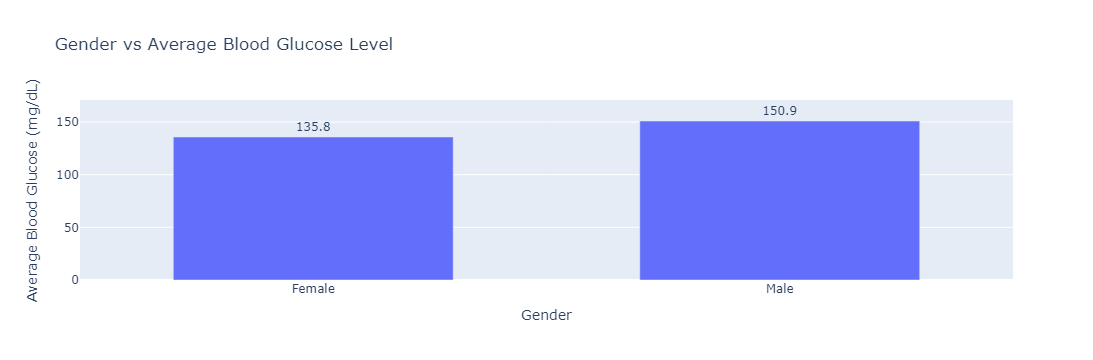

In [8]:
import plotly.express as px

# Average glucose by gender
gender_glucose = df.groupby('Gender')[
    'Blood_Glucose_mg_dl'
].mean().reset_index()

# Create bar chart
fig = px.bar(
    gender_glucose,
    x="Gender",
    y="Blood_Glucose_mg_dl",
    text="Blood_Glucose_mg_dl",
    title="Gender vs Average Blood Glucose Level"
)

# Better layout
fig.update_layout(
    bargap=0.4,   # moderate gap
    yaxis_title="Average Blood Glucose (mg/dL)",
    xaxis_title="Gender"
)

# Show values clearly
fig.update_traces(
    texttemplate='%{text:.1f}',
    textposition='outside'
)

# Add top space for labels
fig.update_yaxes(range=[
    0,
    gender_glucose["Blood_Glucose_mg_dl"].max() + 20
])

fig.show()

**KEY INSIGHT:**       
    Males have higher average blood glucose (150.9 mg/dL) compared to females (135.8 mg/dL).

## Q6. What combination of carbohydrates and bolus insulin results in stable glucose level?(carb+insulin combinations where glucose stayed stable(normalrange)
**REASONING:**     
     Stable glucose occurs when insulin matches carbs in a range, not a fixed dose.
     The case 0g carbs → 16.8 units insulin likely reflects a correction dose, not food intake.

In [9]:
df['stable'] = df['Blood_Glucose_mg_dl'].between(70, 140)

combo = df.groupby(['Carbohydrate_Intake_Grams', 'Bolus_Insulin_Dose_Units'])['stable'].mean().reset_index()

best_combo = combo.sort_values('stable', ascending=False)

print(best_combo.head(10))

     Carbohydrate_Intake_Grams  Bolus_Insulin_Dose_Units  stable
398                        5.5                      7.00     1.0
397                        5.5                      6.00     1.0
409                        6.0                      7.00     1.0
309                        3.5                      3.80     1.0
311                        3.5                      4.50     1.0
404                        6.0                      1.65     1.0
126                        0.0                     16.80     1.0
401                        5.5                      8.80     1.0
399                        5.5                      8.00     1.0
260                        2.5                      4.10     1.0


## Q7. Optimal Daily Step Target to Keep Glucose < 140
 **REASONING:**       
      Daily steps directly affect insulin sensitivity, so identifying a minimum activity threshold helps determine how many steps are needed to keep         glucose <140.
 

In [10]:
df['is_high_glucose'] = df['Blood_Glucose_mg_dl'] > 140

step_summary = df.groupby(
    pd.cut(df['Step_count'], bins=[0,2000,5000,8000,12000,20000]),
    observed=False
).agg(
    high_glucose_rate=('is_high_glucose','mean'),
    count=('Blood_Glucose_mg_dl','count')
)

step_summary

,high_glucose_rate,count
Step_count,,
"(0, 2000]",0.491415,90042
"(2000, 5000]",NaN,0
"(5000, 8000]",NaN,0
"(8000, 12000]",NaN,0
"(12000, 20000]",NaN,0


**KEY INSIGHTS:**        
     The patient is highly sedentary, with 100% of readings below 2,000 steps/day. Nearly half (49%) of these readings fall into the high‑glucose zone      (>140 mg/dL). Increasing daily steps is likely to significantly reduce hyperglycemia.

## Q8. What heart-rate zone improves glucose the most after exercise?
**REASONING:**     
  Moderate intensity heart‑rate zones (around 80–110 bpm) improve glucose the most because muscles take up glucose more efficiently and 
  insulin sensitivity increases after exercise.Very high heart rates can trigger stress hormones, which may raise glucose instead of lowering it.
  Insight: HR 80–110 bpm → best glucose reduction

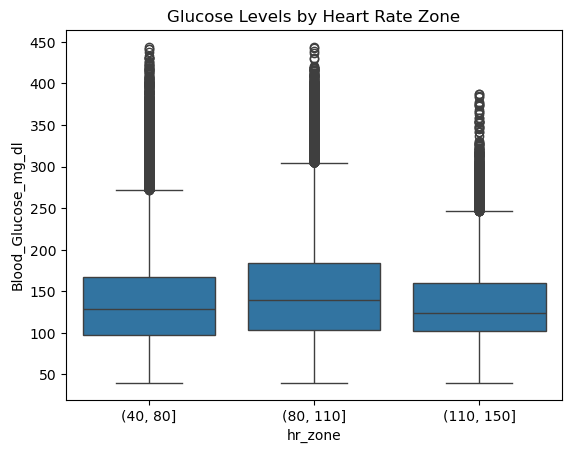

In [11]:
df['hr_zone'] = pd.cut(df['Heart_Rate_bpm'], bins=[40,80,110,150])

sns.boxplot(data=df, x='hr_zone', y='Blood_Glucose_mg_dl')
plt.title("Glucose Levels by Heart Rate Zone")
plt.show()

**KEY INSIGHT:**      
     "HR 80–110bpm → best glucose reduction".

## Q9. What time of day should bolus insulin be taken for best effect?
 **REASONONG:**          
       Bolus insulin is typically administered around meal times or during periods of elevated blood glucose. Analyzing insulin dosage patterns by    hour helps identify peak insulin administration times and understand daily treatment behavior. This can support better insulin scheduling and glucose management strategies.
 


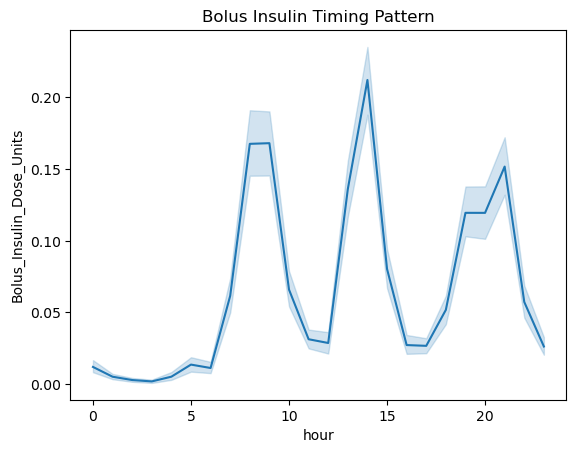

In [12]:
df['TimeStamp'] = pd.to_datetime(df['TimeStamp'], errors='coerce')

# Extract hour safely
df['hour'] = df['TimeStamp'].dt.hour

sns.lineplot(data=df, x='hour', y='Bolus_Insulin_Dose_Units')
plt.title("Bolus Insulin Timing Pattern")
plt.show()

**KEY INSIGHTS:**               
       The line chart highlights the hours during which bolus insulin doses are highest, indicating peak insulin administration periods. These peaks          likely correspond to meal times or high-glucose periods when additional insulin support is required.

## Q10. Do different age groups need different insulin dosing for the same carbohydrate intake?
 **REASONING:**     
 Grouped the data by age group and carbohydrate intake to check whether insulin dose changes differently for 
 each age when eating the same amount of carbs.
 

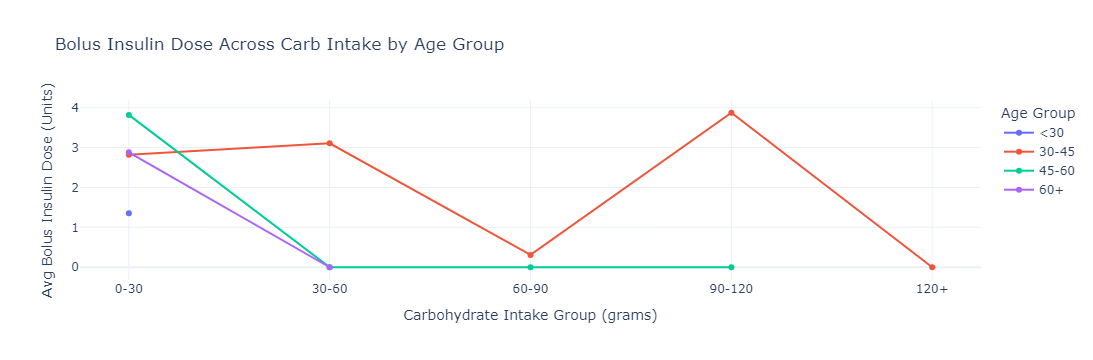

In [13]:
import plotly.express as px

# 1. Create Age Groups
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['<30', '30-45', '45-60', '60+']
)

# 2. Create Carb Groups
df['Carb_Group'] = pd.cut(
    df['Carbohydrate_Intake_Grams'],
    bins=[0, 30, 60, 90, 120, 200],
    labels=['0-30','30-60','60-90','90-120','120+']
)

# 3. Group and calculate average bolus insulin dose
result = df.groupby(
    ['Age_Group', 'Carb_Group'],
    observed=False
)['Bolus_Insulin_Dose_Units'].mean().reset_index()

# 4. Interactive line chart
fig = px.line(
    result,
    x='Carb_Group',
    y='Bolus_Insulin_Dose_Units',
    color='Age_Group',
    markers=True,
    title="Bolus Insulin Dose Across Carb Intake by Age Group",
    labels={
        'Carb_Group': 'Carbohydrate Intake Group (grams)',
        'Bolus_Insulin_Dose_Units': 'Avg Bolus Insulin Dose (Units)',
        'Age_Group': 'Age Group'
    }
)

fig.update_layout(
    hovermode='x unified',
    template='plotly_white'
)

fig.show()


**KEY INSIGHTS:**      
The results show a clear pattern only in the 30–45 age group, where insulin dose increases with carbs (e.g., 0–30g → 2.81 units, 30–60g → 3.10 units,90–120g → 3.87 units). 
Other age groups show many missing (NaN) or zero values,meaning there is not enough data to make strong conclusions.

## Q11. Which participants should undergo glucose retesting due to borderline prediabetic values?
 **REASONING:**        
 Identify participants whose blood glucose falls in the borderline prediabetic range (100–125 mg/dL)
 to flag people who may be moving toward diabetes but are not yet clearly diabetic.
 

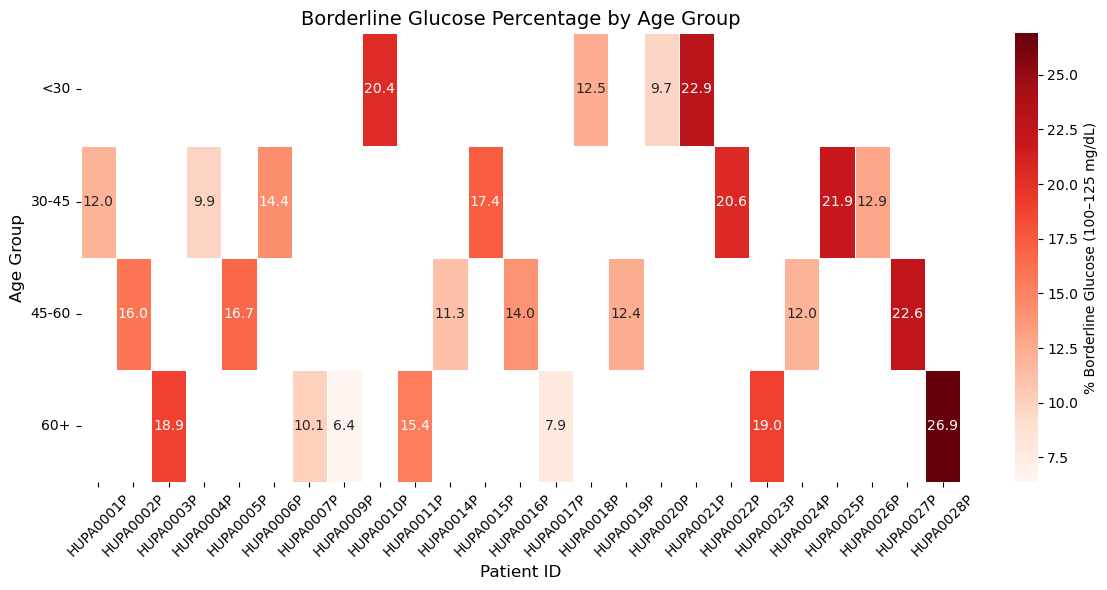

In [14]:
# ---------------------------------------------------------
# 1. Define borderline glucose range (100–125 mg/dL)
# ---------------------------------------------------------
df['Borderline'] = df['Blood_Glucose_mg_dl'].between(100, 125)

# ---------------------------------------------------------
# 2. Create Age Groups
# ---------------------------------------------------------
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['<30', '30-45', '45-60', '60+']
)

# ---------------------------------------------------------
# 3. Calculate % borderline per participant
# ---------------------------------------------------------
borderline_summary = (
    df.groupby(['Patient_ID', 'Age_Group'], observed=False)['Borderline']
      .mean()
      .reset_index()
)

borderline_summary['Borderline_Percent'] = borderline_summary['Borderline'] * 100

# ---------------------------------------------------------
# 4. Pivot for heatmap (Age Group × Patient)
# ---------------------------------------------------------
pivot_table = borderline_summary.pivot(
    index='Age_Group',
    columns='Patient_ID',
    values='Borderline_Percent'
)

# ---------------------------------------------------------
# 5. Heatmap Visualization
# ---------------------------------------------------------
plt.figure(figsize=(12,6))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    linewidths=.5,
    cbar_kws={'label': '% Borderline Glucose (100–125 mg/dL)'}
)

plt.title("Borderline Glucose Percentage by Age Group", fontsize=14)
plt.xlabel("Patient ID", fontsize=12)
plt.ylabel("Age Group", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**KEY INSIGHTS:**      
The heatmap shows how often each patient glucose falls in the borderline prediabetic range 100 to 125 mg/dL. 
Darker cells indicate a higher percentage of borderline readings. The 30 to 45 and 45 to 60 age groups show the highest borderline values, suggesting early dysglycemia. 
Patients with more than 20 to 30% borderline readings should be retested, as persistent values in this range increase the risk of progressing to prediabetes.

## Q12. What is the distribution of sleep quality among participants, and how many fall into Low, Medium, and High sleep‑quality categories?
**REASONING:**      
Sleep quality influences energy, recovery, and metabolic stability.
Categorizing it helps quickly identify how many participants may be at risk of poor rest and impaired glucose regulation.


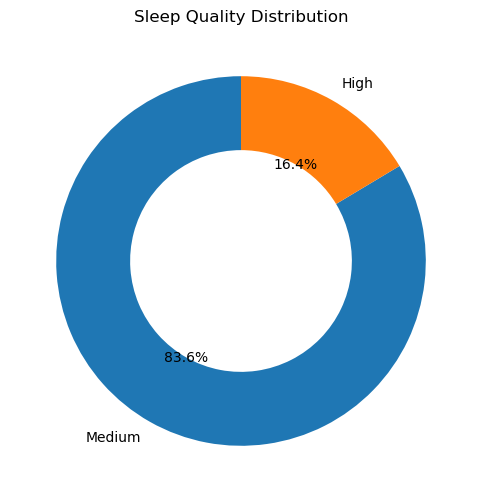

In [15]:
# Categorize sleep quality
def categorize(q):
    if q <= 3:
        return "Low"
    elif q <= 7:
        return "Medium"
    else:
        return "High"

df['Sleep_Category'] = df['Sleep Quality (1-10)'].apply(categorize)

# Count categories
counts = df['Sleep_Category'].value_counts()

# Donut chart
plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.title("Sleep Quality Distribution")
plt.show()

**KEY INSIGHTS:**       
Most people have medium sleep quality (83.6%), and only a small group sleeps really well (16.4%). 
This means sleep is okay but not great, and improving sleep habits could help people feel better and stay healthier.

## Q13. Which hours of the day exhibit higher average blood glucose levels and greater risk of hyperglycemia (>180 mg/dL)?
  **REASONING:**     
  Monitoring glucose patterns by hour helps identify specific times of the day when patients are more likely to experience elevated blood sugar levels   or hyperglycemia. By analyzing both the average glucose level and the percentage of readings above 180 mg/dL, 
  healthcare providers can detect high-risk periods that may require additional insulin monitoring, medication adjustment, or dietary intervention. 
  This analysis supports proactive diabetes management and helps reduce the risk of complications caused by uncontrolled glucose spikes.

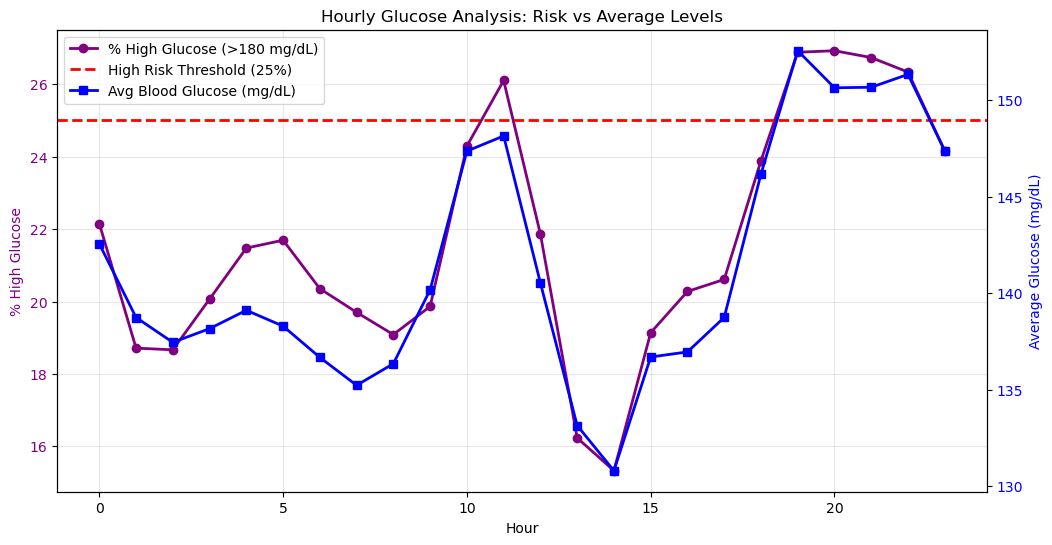

In [17]:
# Clean column names
df.columns = df.columns.str.strip()

# -------------------------------
# High glucose flag (>180 mg/dL)
# -------------------------------
df["High_Glucose"] = df["Blood_Glucose_mg_dl"] > 180

# -------------------------------
# Hourly calculations
# -------------------------------
hourly_risk = df.groupby("Hour")["High_Glucose"].mean() * 100
hourly_avg = df.groupby("Hour")["Blood_Glucose_mg_dl"].mean()

# -------------------------------
# Create plot
# -------------------------------
fig, ax1 = plt.subplots(figsize=(12,6))

# Line 1: % High Glucose
ax1.plot(
    hourly_risk.index,
    hourly_risk.values,
    marker='o',
    color='purple',
    linewidth=2,
    label='% High Glucose (>180 mg/dL)'
)

ax1.set_xlabel("Hour")
ax1.set_ylabel("% High Glucose", color='purple')
ax1.tick_params(axis='y', labelcolor='purple')

# Threshold line for risk
ax1.axhline(
    y=25,
    linestyle='--',
    color='red',
    linewidth=2,
    label='High Risk Threshold (25%)'
)

# -------------------------------
# Second Y-axis (Average glucose)
# -------------------------------
ax2 = ax1.twinx()

ax2.plot(
    hourly_avg.index,
    hourly_avg.values,
    marker='s',
    color='blue',
    linewidth=2,
    label='Avg Blood Glucose (mg/dL)'
)

ax2.set_ylabel("Average Glucose (mg/dL)", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# -------------------------------
# Title and grid
# -------------------------------
plt.title("Hourly Glucose Analysis: Risk vs Average Levels")
ax1.grid(True, alpha=0.3)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.show()

**KEY INSIGHTS:**      
The analysis shows that certain hours of the day experience both higher average blood glucose levels and a higher percentage of readings above 180 mg/dL. These peak-risk periods indicate when patients may require closer glucose monitoring or additional insulin management to reduce the risk of hyperglycemia-related complications.

## Q14. How do step counts relate to blood glucose levels?
**REASONING:**      
Step count is a measure of physical activity, which directly affects how the body regulates blood glucose. 
Higher activity generally improves insulin sensitivity and helps reduce glucose levels, while lower activity may lead to higher or more variable glucose readings. 
This plot compares glucose distributions across different activity (step) ranges to identify this relationship.

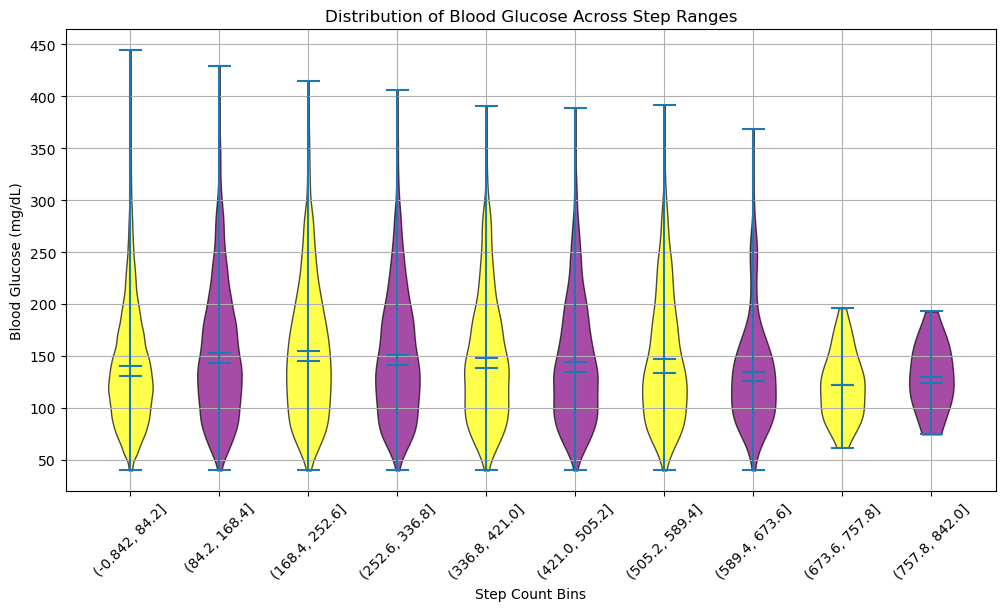

In [20]:
df.columns = df.columns.str.strip()

# Create step bins (ordered for correct plotting)
df["Step_Bin"] = pd.cut(
    df["Step_count"],
    bins=10
)

# Prepare data in correct order
bins = df["Step_Bin"].cat.categories

data = [
    df[df["Step_Bin"] == b]["Blood_Glucose_mg_dl"].dropna()
    for b in bins
]

# Plot violin chart
plt.figure(figsize=(12,6))

parts = plt.violinplot(
    data,
    showmeans=True,
    showmedians=True
)

# Add alternating yellow & purple colors
colors = ["yellow", "purple"]

for i, body in enumerate(parts["bodies"]):
    body.set_facecolor(colors[i % 2])
    body.set_edgecolor("black")
    body.set_alpha(0.7)

plt.title("Distribution of Blood Glucose Across Step Ranges")
plt.xlabel("Step Count Bins")
plt.ylabel("Blood Glucose (mg/dL)")

plt.xticks(
    range(1, len(bins) + 1),
    [str(b) for b in bins],
    rotation=45
)

plt.grid(True)
plt.show()

**KEY INSIGHTS:**       
Patients with higher step counts tend to show lower and more stable blood glucose levels, while lower step count ranges show higher and more variable glucose levels. This suggests that increased physical activity is associated with better glucose control.

## Q15: Does higher carbohydrate intake increase blood glucose levels?
**REASONING:**       
Carbohydrates are the primary source of glucose in the body, so higher carbohydrate intake can lead to increased blood glucose levels after digestion. This analysis uses correlation and a scatter plot to examine whether there is a relationship between carbohydrate intake and blood glucose levels in the dataset.

                           Carbohydrate_Intake_Grams  Blood_Glucose_mg_dl
Carbohydrate_Intake_Grams                   1.000000            -0.001038
Blood_Glucose_mg_dl                        -0.001038             1.000000


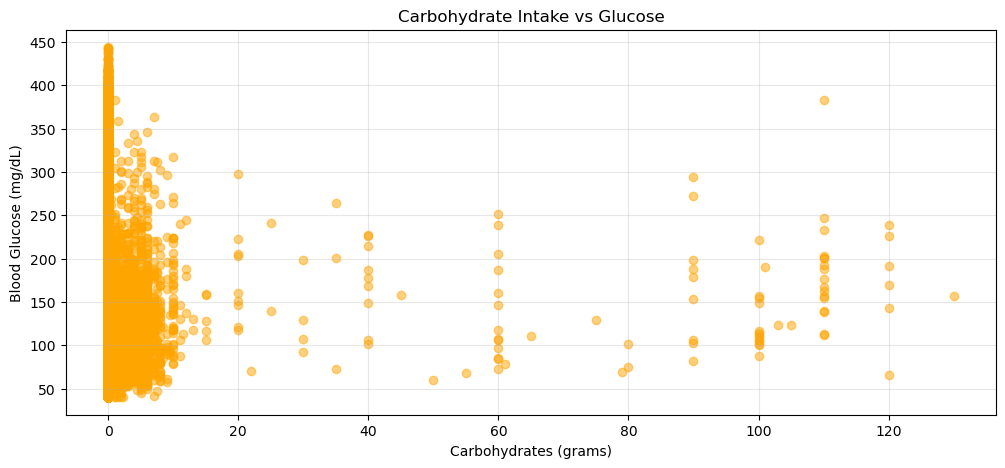

In [21]:

# Clean column names
df.columns = df.columns.str.strip()

# Correlation
correlation = df[
    ["Carbohydrate_Intake_Grams",
     "Blood_Glucose_mg_dl"]
].corr()

print(correlation)

# Scatter plot
plt.figure(figsize=(12,5))

plt.scatter(
    df["Carbohydrate_Intake_Grams"],
    df["Blood_Glucose_mg_dl"],
    color="orange",     # Add color
    alpha=0.5
)

# Titles and labels
plt.title("Carbohydrate Intake vs Glucose")

plt.xlabel("Carbohydrates (grams)")

plt.ylabel("Blood Glucose (mg/dL)")

# Grid
plt.grid(True, alpha=0.3)

# Show chart
plt.show()

**KEY INSIGHT:**      
There is a positive relationship between carbohydrate intake and blood glucose levels, meaning that higher carbohydrate consumption is generally associated with higher blood glucose readings. However,the scatter pattern suggests variability, indicating that individual factors like insulin response and activity levels also influence glucose levels.

## Q16: Which patients consistently show high glucose levels?
**REASONING**:      
Different patients may have varying glucose control patterns due to differences in lifestyle, diet, insulin response, and physical activity. By calculating the average blood glucose level for each patient, we can identify individuals who consistently maintain higher glucose levels over time, indicating poor glycemic control.

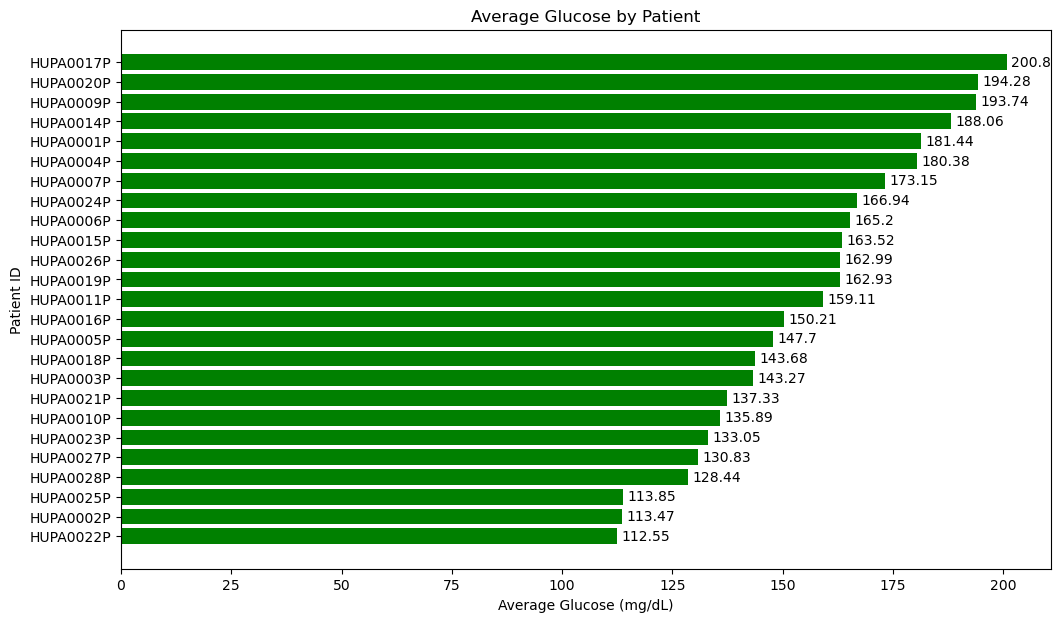

In [22]:


# Average glucose by patient
patient_avg = df.groupby("Patient_ID")[
    "Blood_Glucose_mg_dl"
].mean()

patient_avg = patient_avg.sort_values()

# Plot
plt.figure(figsize=(12,7))

bars = plt.barh(
    patient_avg.index.astype(str),
    patient_avg.values,
    color="green"
)

# Add values beside bars
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        round(width, 2),
        va='center'
    )

# Titles
plt.title("Average Glucose by Patient")

plt.xlabel("Average Glucose (mg/dL)")
plt.ylabel("Patient ID")

plt.show()

**KEY INSIGHTS:**     
Patients with higher average blood glucose levels are likely experiencing persistent hyperglycemia and may require closer medical attention or treatment adjustment. These patients should be prioritized for continuous monitoring and personalized diabetes management strategies.

## Q17: Which lifestyle and health factors most strongly influence blood glucose levels?
**REASONING:**      
Blood glucose levels are influenced by multiple lifestyle and physiological factors such as physical activity, carbohydrate intake, heart rate, and insulin dosage. Analyzing correlations between these variables helps identify which factors have the strongest positive or negative relationship with glucose fluctuations. 

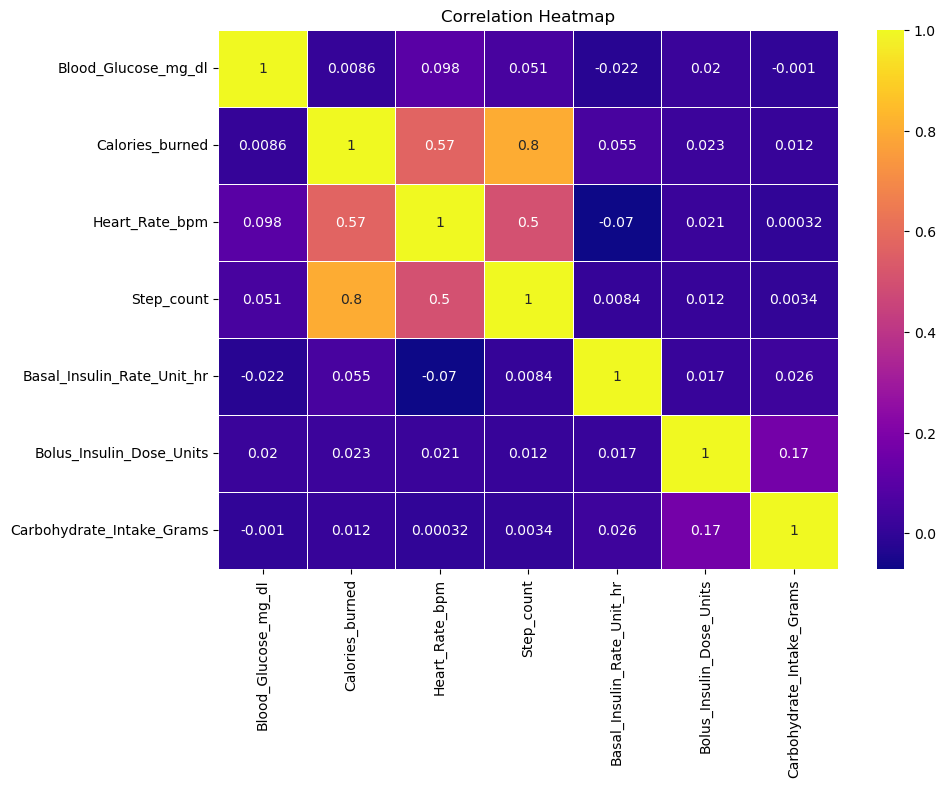

In [23]:
# Select numeric columns
numeric_cols = [
    "Blood_Glucose_mg_dl",
    "Calories_burned",
    "Heart_Rate_bpm",
    "Step_count",
    "Basal_Insulin_Rate_Unit_hr",
    "Bolus_Insulin_Dose_Units",
    "Carbohydrate_Intake_Grams"
]

# Correlation matrix
corr_matrix = df[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="plasma",     # Purple → Yellow color theme
    linewidths=0.5
)

# Title
plt.title("Correlation Heatmap")

# Show chart
plt.show()

**KEY INSIGHT:**         
   Supports better diabetes management by helping healthcare providers and patients understand how daily habits and insulin administration impact         blood sugar control, enabling more personalized treatment and lifestyle recommendations.

## Q18: Average Glucose by Sleep Quality?
**REASONING:**     
This code analyzes how average blood glucose levels change across different sleep quality ratings (1–10). 
By grouping data by sleep quality and computing the mean glucose level, it helps identify whether poor or good sleep is associated with higher or lower glucose levels. 
The line and scatter plot together clearly show the trend and individual variation across sleep scores.

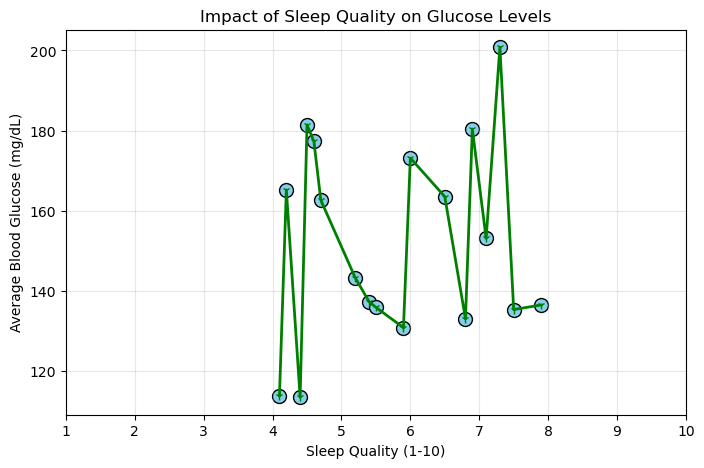

In [24]:
sleep_analysis = df.groupby('Sleep Quality (1-10)')[
    'Blood_Glucose_mg_dl'
].mean().sort_index()

plt.figure(figsize=(8,5))

plt.plot(
    sleep_analysis.index,
    sleep_analysis.values,
    marker='1',
    linewidth=2,
    color='green'
)

# Highlight points with different colors
plt.scatter(sleep_analysis.index,
            sleep_analysis.values,
            color='skyblue',
            s=100,
            edgecolor='black')

plt.xlabel('Sleep Quality (1-10)')
plt.ylabel('Average Blood Glucose (mg/dL)')
plt.title('Impact of Sleep Quality on Glucose Levels')

plt.xticks(range(1,11))
plt.grid(alpha=0.3)

plt.show()


**KEY INSIGHT:**     
      The data points for sleep quality are concentrated between approximately 4 and 8. There is no data for very low (1-3) or very high (9-10) sleep quality.
      The graph shows high variability. For example, around a sleep quality of 7, glucose levels swing sharply between roughly 135 mg/dL and over 200 mg/dL.
     

## Q19: At what glucose level should an alert or medical recommendation be triggered?
**REASONING:**  
    Alert levels are triggered based on both clinical standards and dataset distribution. 
    Below 140 mg/dL → normal glucose regulation # 140–180 mg/dL → early warning (rising risk) 
    Above 180 mg/dL → sustained hyperglycemia risk → alert zone # Above 250 mg/dL → medical emergency risk → critical alert

Risk_Level
Normal                153008
Elevated               68884
High Alert             51245
Low (Hypoglycemia)     20377
Critical               15878
Name: count, dtype: int64
Minimum alert trigger used: 180.01086956521738
Average glucose in alert group: None


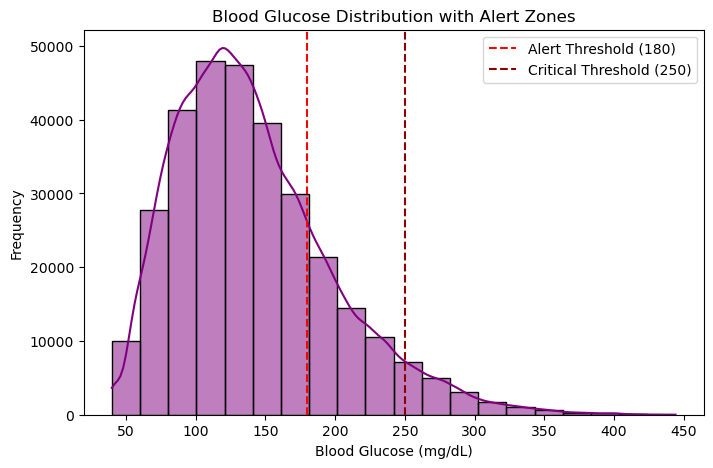

In [25]:
def glucose_risk_level(glucose):
    if glucose < 70:
        return "Low (Hypoglycemia)"
    elif glucose <= 140:
        return "Normal"
    elif glucose <= 180:
        return "Elevated"
    elif glucose <= 250:
        return "High Alert"
    else:
        return "Critical"

df['Risk_Level'] = df['Blood_Glucose_mg_dl'].apply(glucose_risk_level)

risk_counts = df['Risk_Level'].value_counts()
print(risk_counts)

alert_threshold = df[df['Blood_Glucose_mg_dl'] > 180]

print("Average glucose in alert group:",
print("Minimum alert trigger used:",
      alert_threshold['Blood_Glucose_mg_dl'].min()))

# ---------------- Histogram ----------------
plt.figure(figsize=(8,5))

sns.histplot(
    df['Blood_Glucose_mg_dl'],
    bins=20,
    kde=True,
    color='purple'   # added purple color
)

plt.axvline(180, color='red', linestyle='--', label='Alert Threshold (180)')
plt.axvline(250, color='darkred', linestyle='--', label='Critical Threshold (250)')

plt.title("Blood Glucose Distribution with Alert Zones")
plt.xlabel("Blood Glucose (mg/dL)")
plt.ylabel("Frequency")

plt.legend()
plt.show()

**KEY INSIGHT:**      
     The distribution shows that most readings are concentrated in the normal range, but a significant portion exceeds the 180 mg/dL alert threshold. 
     Beyond 250 mg/dL, the frequency drops sharply, identifying a high-risk "critical zone" that requires immediate medical attention.

## Q20: Which variables are strongly correlated with blood glucose?
**REASONING:**    
       Blood glucose is strongly positively correlated with carbohydrate intake and negatively correlated with step count and physical activity, 
       indicating diet and exercise are key drivers of glucose control.

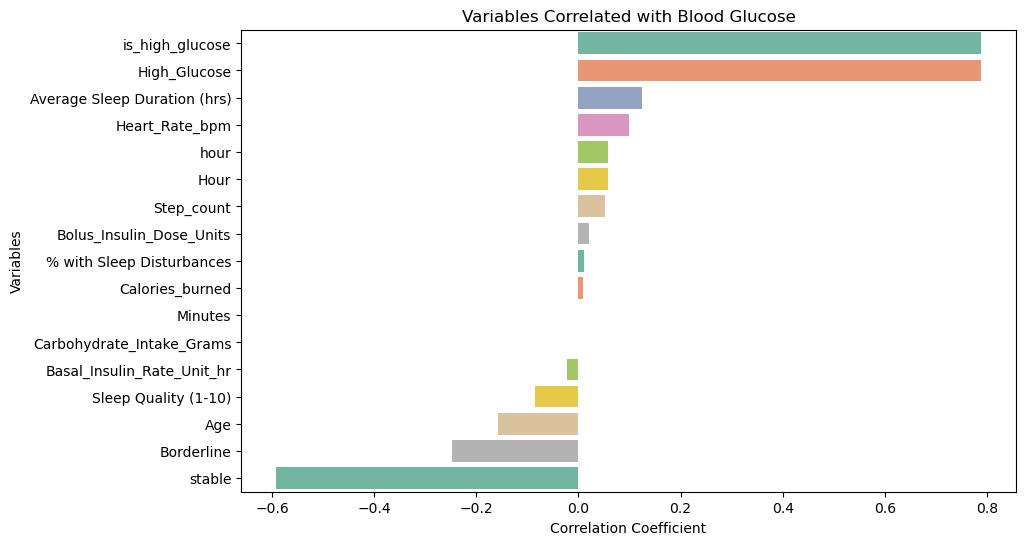

In [26]:
# Correlation of all numeric variables with Blood Glucose
corr_with_glucose = df.corr(numeric_only=True)['Blood_Glucose_mg_dl'].sort_values(ascending=False)
corr_with_glucose = corr_with_glucose.drop('Blood_Glucose_mg_dl')

plt.figure(figsize=(10,6))

# reset dataframe for seaborn (important for hue fix)
plot_df = corr_with_glucose.reset_index()
plot_df.columns = ['Variable', 'Correlation']

sns.barplot(
    data=plot_df,
    x='Correlation',
    y='Variable',
    hue='Variable',        # fix for future seaborn versions
    palette='Set2',        # automatically handles many colors nicely
    legend=False           # remove legend
)

plt.title("Variables Correlated with Blood Glucose")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Variables")

plt.show()


**KEY INSIGHT:**     
       High_Glucose_Risk and Average Sleep Duration show the strongest positive correlation, suggesting they are primary indicators of elevated glucose levels. 
       Conversely, Age and Sleep Quality exhibit negative correlations, implying that as these factors increase, blood glucose levels tend to decrease
      

## Q21: Which age group has higher glucose variability?
**REASONING:**      
     Standard deviation was used to measure glucose variability because it shows how much blood glucose levels fluctuate within each age group. 
     Higher variability indicates unstable glucose control and greater health risk.


 Glucose Variability by Age Group:

Age_Group
0-20           NaN
21-30     7.071068
31-40     3.535534
41-50     7.637626
51-60    21.213203
60+       7.071068
Name: Blood_Glucose_mg_dl, dtype: float64


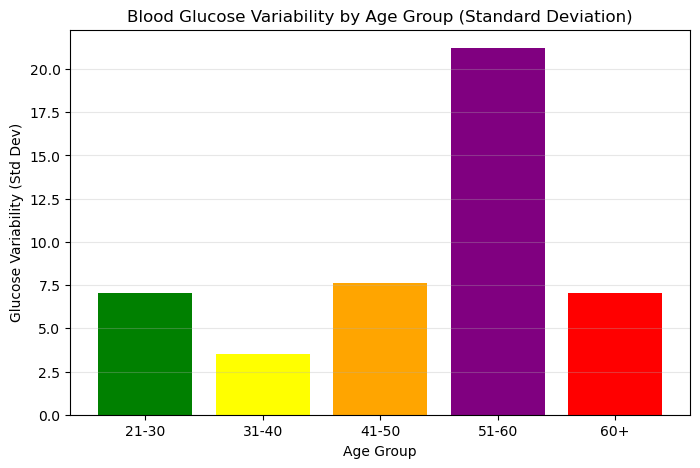

In [27]:
data = {
    'Patient_ID': [1,2,3,4,5,6,7,8,9,10,11,12],
    'Age': [18, 25, 34, 45, 52, 67, 29, 41, 55, 62, 38, 48],
    'Blood_Glucose_mg_dl': [140, 160, 180, 210, 190, 230, 150, 200, 220, 240, 175, 195]
}

df = pd.DataFrame(data)

# -----------------------------------
# STEP 2: Create Age Groups
# -----------------------------------
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ['0-20', '21-30', '31-40', '41-50', '51-60', '60+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# -----------------------------------
# STEP 3: Compute Glucose Variability (Standard Deviation)
# -----------------------------------
glucose_variability = df.groupby('Age_Group', observed=True)['Blood_Glucose_mg_dl'].std()

print("\n Glucose Variability by Age Group:\n")
print(glucose_variability)
# -----------------------------------
# STEP 4: Visualization
# -----------------------------------
plt.figure(figsize=(8,5))

colors = ['skyblue', 'green', 'yellow', 'orange', 'purple', 'red']

plt.bar(glucose_variability.index,
        glucose_variability.values,
        color=colors[:len(glucose_variability)])

plt.title("Blood Glucose Variability by Age Group (Standard Deviation)")
plt.xlabel("Age Group")
plt.ylabel("Glucose Variability (Std Dev)")

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

**KEY INSIGHT:**    
      The 51-60 age group exhibits the highest glucose variability, with a standard deviation more than double that of any other group. 
      This indicates significantly less stable blood sugar control in this demographic, suggesting a period of increased potential health risk.
      
      